In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/driver_race_features.csv"
)

print("shape:",df.shape)

shape: (2618, 22)


In [4]:
print(df.columns.to_list())
df.info()

['DriverNumber', 'Abbreviation', 'DriverId', 'TeamName', 'TeamId', 'FirstName', 'LastName', 'FullName', 'Position', 'ClassifiedPosition', 'GridPosition', 'Time', 'Status', 'Points', 'Laps', 'Year', 'Race', 'QualifyingPosition', 'Q1', 'Q2', 'Q3', 'BestQualifyingTime']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DriverNumber        2618 non-null   int64  
 1   Abbreviation        2618 non-null   object 
 2   DriverId            2618 non-null   object 
 3   TeamName            2618 non-null   object 
 4   TeamId              2618 non-null   object 
 5   FirstName           2618 non-null   object 
 6   LastName            2618 non-null   object 
 7   FullName            2618 non-null   object 
 8   Position            2615 non-null   float64
 9   ClassifiedPosition  2618 non-null   object 
 10  GridPosition        2615 non-nul

In [5]:
correlation = df[["GridPosition","Position"]].corr()
print(correlation)

              GridPosition  Position
GridPosition       1.00000   0.59836
Position           0.59836   1.00000


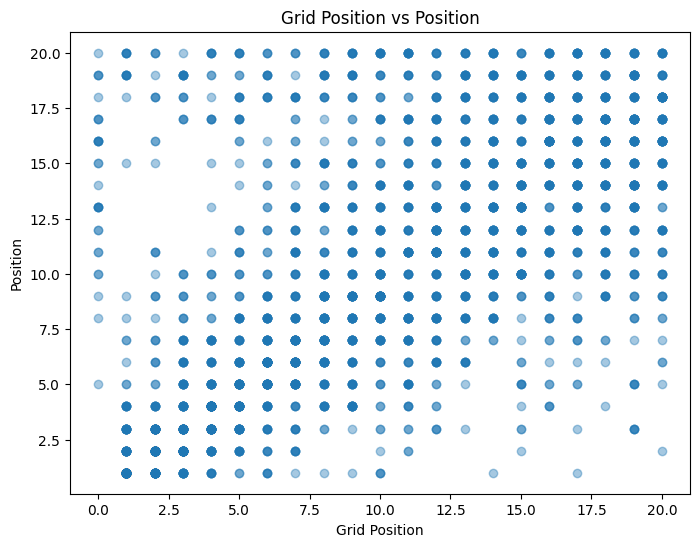

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["GridPosition"],
    df["Position"],
    alpha=0.4
)

plt.xlabel("Grid Position")
plt.ylabel("Position")
plt.title("Grid Position vs Position")

plt.show()

In [7]:
qualifying_correlation = df[
    ["QualifyingPosition", "Position"]
].corr()
print(qualifying_correlation)

                    QualifyingPosition  Position
QualifyingPosition            1.000000  0.639615
Position                      0.639615  1.000000


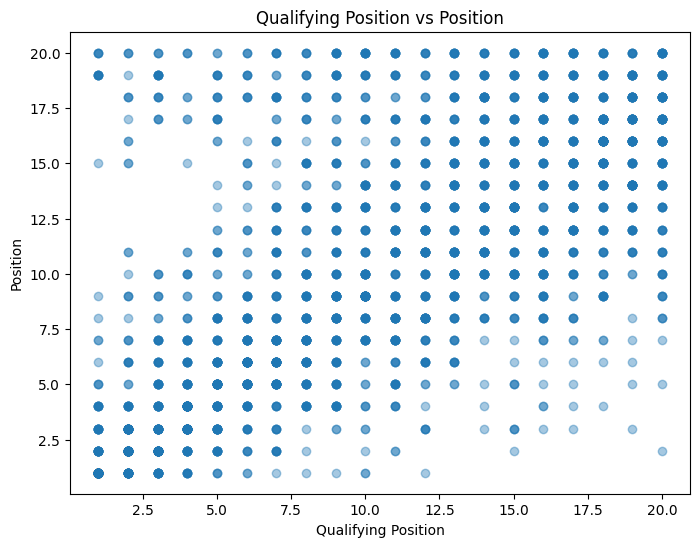

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["QualifyingPosition"],
    df["Position"],
    alpha=0.4
)

plt.xlabel("Qualifying Position")
plt.ylabel("Position")
plt.title("Qualifying Position vs Position")
plt.show()

In [12]:
df["PositionGain"] = (df["QualifyingPosition"]-df["Position"])
print(
    df[
        [
            "FullName",
            "QualifyingPosition",
            "Position",
            "PositionGain"
        ]
    ].head(10)
)

          FullName  QualifyingPosition  Position  PositionGain
0   Max Verstappen                 4.0       1.0           3.0
1   Lewis Hamilton                 2.0       2.0           0.0
2  Valtteri Bottas                 1.0       3.0          -2.0
3  Charles Leclerc                 8.0       4.0           4.0
4  Alexander Albon                 9.0       5.0           4.0
5     Lance Stroll                 6.0       6.0           0.0
6  Nico Hulkenberg                 3.0       7.0          -4.0
7     Esteban Ocon                11.0       8.0           3.0
8     Lando Norris                10.0       9.0           1.0
9     Daniil Kvyat                16.0      10.0           6.0


In [15]:
biggest_gains = df.sort_values(
    "PositionGain",
    ascending=False
).head(10)

print("Biggest position gains:")
print(
    biggest_gains[
        [
            "Year",
            "Race",
            "FullName",
            "QualifyingPosition",
            "Position",
            "PositionGain"
        ]
    ]
)

biggest_losses = df.sort_values(
    "PositionGain",
    ascending=True
).head(10)

print("Biggest position losses:")
print(
    biggest_losses[
        [
            "Year",
            "Race",
            "FullName",
            "QualifyingPosition",
            "Position",
            "PositionGain"
        ]
    ]
)

Biggest position gains:
      Year                      Race         FullName  QualifyingPosition  \
641   2021        russian grand prix   Max Verstappen                20.0   
2261  2025        british grand prix  Nico Hulkenberg                19.0   
1244  2023     australian grand prix     Sergio Perez                20.0   
1484  2023    mexico city grand prix     Lando Norris                19.0   
2421  2025      las vegas grand prix   Kimi Antonelli                17.0   
1663  2024      abu dhabi grand prix   Lewis Hamilton                18.0   
1463  2023      las vegas grand prix     Esteban Ocon                17.0   
1561  2023  saudi arabian grand prix   Max Verstappen                15.0   
2325  2025          dutch grand prix     Lance Stroll                20.0   
2580  2025      são paulo grand prix   Max Verstappen                16.0   

      Position  PositionGain  
641        2.0          18.0  
2261       3.0          16.0  
1244       5.0          15.0  
1484

In [16]:
print("Position Gain Statistics:",df["PositionGain"].describe())
print("\nAverage position gain:",df["PositionGain"].mean())
print("\nMedian position gain:",df["PositionGain"].median())

Position Gain Statistics: count    2593.000000
mean       -0.008484
std         4.882248
min       -19.000000
25%        -2.000000
50%         0.000000
75%         3.000000
max        18.000000
Name: PositionGain, dtype: float64

Average position gain: -0.008484381025838797

Median position gain: 0.0


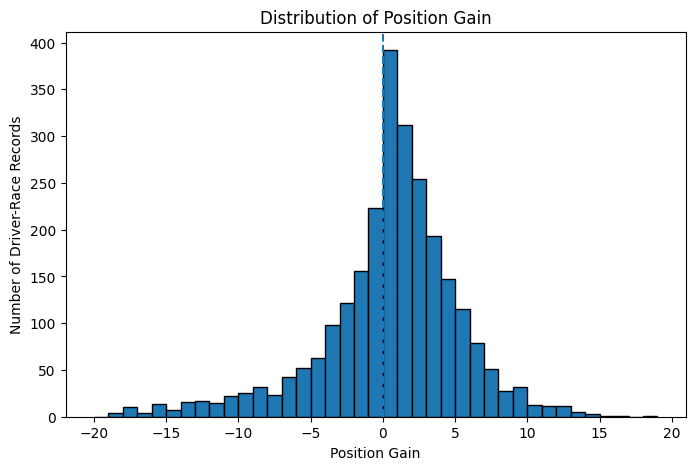

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["PositionGain"].dropna(),
    bins=range(-20, 20),
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Position Gain")
plt.ylabel("Number of Driver-Race Records")
plt.title("Distribution of Position Gain")

plt.show()

In [18]:
extreme_changes = df[
    df["PositionGain"].abs() >= 10
][
    [
        "Year",
        "Race",
        "FullName",
        "QualifyingPosition",
        "Position",
        "PositionGain",
        "Status"
    ]
].sort_values(
    "PositionGain"
)

print(extreme_changes.to_string(index=False))

 Year                      Race              FullName  QualifyingPosition  Position  PositionGain           Status
 2021         monaco grand prix       Charles Leclerc                 1.0      20.0         -19.0       Driveshaft
 2023  united states grand prix       Charles Leclerc                 1.0      20.0         -19.0     Disqualified
 2022        spanish grand prix       Charles Leclerc                 1.0      20.0         -19.0            Turbo
 2022  united states grand prix          Carlos Sainz                 1.0      20.0         -19.0 Collision damage
 2022         french grand prix       Charles Leclerc                 1.0      19.0         -18.0         Accident
 2020          eifel grand prix       Valtteri Bottas                 1.0      19.0         -18.0       Power Unit
 2022     azerbaijan grand prix       Charles Leclerc                 1.0      19.0         -18.0       Power Unit
 2021        british grand prix        Max Verstappen                 2.0      2

In [19]:
status_counts = extreme_changes["Status"].value_counts()

print(status_counts)

Status
Finished            47
Retired             42
Collision           18
Disqualified         8
Lapped               7
Accident             6
Engine               6
Power Unit           6
Collision damage     5
Gearbox              3
Suspension           3
+1 Lap               3
Hydraulics           2
Electronics          2
Fuel pressure        2
Did not start        2
Undertray            2
Water pressure       1
Damage               1
Driveshaft           1
Turbo                1
Fuel leak            1
+2 Laps              1
Wheel nut            1
Overheating          1
Exhaust              1
Puncture             1
Radiator             1
Spun off             1
Differential         1
Brakes               1
Power loss           1
Name: count, dtype: int64
